In [10]:
import os
import shutil
from glob import glob
import kagglehub
import cv2
import numpy as np

In [2]:
# Dataset indir
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")

print("Dataset indirildi:", path)

Dataset indirildi: C:\Users\dellg\.cache\kagglehub\datasets\aryashah2k\breast-ultrasound-images-dataset\versions\1


In [6]:
project_dir = r"C:\ornekler\jupyter\deep_learning\breast-cancer"

# Dataseti proje içine kopyala
dataset_dir = os.path.join(project_dir, "Dataset_BUSI_with_GT")

if not os.path.exists(dataset_dir):
    shutil.copytree(path, dataset_dir)

print("Dataset proje klasörüne kopyalandı.")

Dataset proje klasörüne kopyalandı.


In [18]:
project_dir = r"C:\ornekler\jupyter\deep_learning\breast-cancer"
processed_dir = os.path.join(project_dir, "processed")

seg_img_dir = os.path.join(processed_dir, "segmentation/images")
seg_mask_dir = os.path.join(processed_dir, "segmentation/masks")

cls_benign_dir = os.path.join(processed_dir, "classification/benign")
cls_malignant_dir = os.path.join(processed_dir, "classification/malignant")
cls_normal_dir = os.path.join(processed_dir, "classification/normal")

# klasörleri oluştur
for d in [seg_img_dir, seg_mask_dir,
          cls_benign_dir, cls_malignant_dir, cls_normal_dir]:
    os.makedirs(d, exist_ok=True)

print("Processed klasör yapısı hazır.")

Processed klasör yapısı hazır.


In [22]:
import os
import cv2
import shutil
import numpy as np
from glob import glob

# ─── Yollar ───────────────────────────────────────────────────────────────────
project_dir   = r"C:\ornekler\jupyter\deep_learning\breast-cancer"
dataset_dir   = os.path.join(project_dir, "Dataset_BUSI_with_GT")
processed_dir = os.path.join(project_dir, "processed")

seg_img_dir  = os.path.join(processed_dir, "segmentation", "images")
seg_mask_dir = os.path.join(processed_dir, "segmentation", "masks")
cls_dirs = {
    "benign":    os.path.join(processed_dir, "classification", "benign"),
    "malignant": os.path.join(processed_dir, "classification", "malignant"),
    "normal":    os.path.join(processed_dir, "classification", "normal"),
}

# ─── Birden fazla maskesi olan görselleri birleştir ve kaydet ─────────────────
def process_and_save(dataset_dir, seg_img_dir, seg_mask_dir, cls_dirs, size=256):
    categories = ["benign", "malignant", "normal"]
    stats = {c: 0 for c in categories}
    
    for category in categories:
        cat_dir = os.path.join(dataset_dir, category)
        if not os.path.exists(cat_dir):
            print(f"[UYARI] Klasör bulunamadı: {cat_dir}")
            continue

        # Sadece maske olmayan görselleri al (orijinal görüntüler)
        all_files  = sorted(glob(os.path.join(cat_dir, "*.png")))
        image_files = [f for f in all_files if "mask" not in os.path.basename(f)]
        
        for img_path in image_files:
            base_name = os.path.splitext(os.path.basename(img_path))[0]  # örn: benign (1)
            
            # Bu görüntüye ait tüm maskeleri bul
            mask_pattern = os.path.join(cat_dir, f"{base_name}_mask*.png")
            mask_files   = sorted(glob(mask_pattern))
            
            # ── Görüntüyü oku ve yeniden boyutlandır ──
            image = cv2.imread(img_path)
            image = cv2.resize(image, (size, size))
            
            # ── Classification için kaydet (BGR olarak, orijinal renk) ──
            cls_out = os.path.join(cls_dirs[category], f"{category}_{base_name}.png")
            cv2.imwrite(cls_out, image)
            
            # ── Segmentation: görüntüyü grayscale + normalize ──
            img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            img_norm = (img_gray / 255.0 * 255).astype(np.uint8)
            
            seg_img_out = os.path.join(seg_img_dir, f"{category}_{base_name}.png")
            cv2.imwrite(seg_img_out, img_norm)
            
            # ── Maskeleri birleştir ──
            if mask_files:
                combined_mask = np.zeros((size, size), dtype=np.float64)
                for mf in mask_files:
                    m = cv2.imread(mf, cv2.IMREAD_GRAYSCALE)
                    m = cv2.resize(m, (size, size))
                    combined_mask += m / 255.0
                
                # Binary'e çevir (birden fazla maske olunca değer >1 olabilir)
                combined_mask = (combined_mask > 0.5).astype(np.uint8) * 255
            else:
                # Normal sınıfı genellikle maske içermez → siyah maske
                combined_mask = np.zeros((size, size), dtype=np.uint8)
            
            seg_mask_out = os.path.join(seg_mask_dir, f"{category}_{base_name}_mask.png")
            cv2.imwrite(seg_mask_out, combined_mask)
            
            stats[category] += 1
    
    return stats

# ─── Çalıştır ─────────────────────────────────────────────────────────────────
stats = process_and_save(dataset_dir, seg_img_dir, seg_mask_dir, cls_dirs, size=256)

print("\n✅ Veri ayrıştırma tamamlandı!")
for cat, count in stats.items():
    print(f"  {cat:12s}: {count} görüntü işlendi")


✅ Veri ayrıştırma tamamlandı!
  benign      : 437 görüntü işlendi
  malignant   : 210 görüntü işlendi
  normal      : 133 görüntü işlendi


KLASÖR BAZLI DOSYA SAYILARI

Segmentation
  images : 780
  masks  : 780
  Eşleşme: ✅ Tamam

Classification
  benign      : 437
  malignant   : 210
  normal      : 133

Segmentation toplam : 780
Classification toplam: 780
Genel eşleşme       : ✅ Tamam


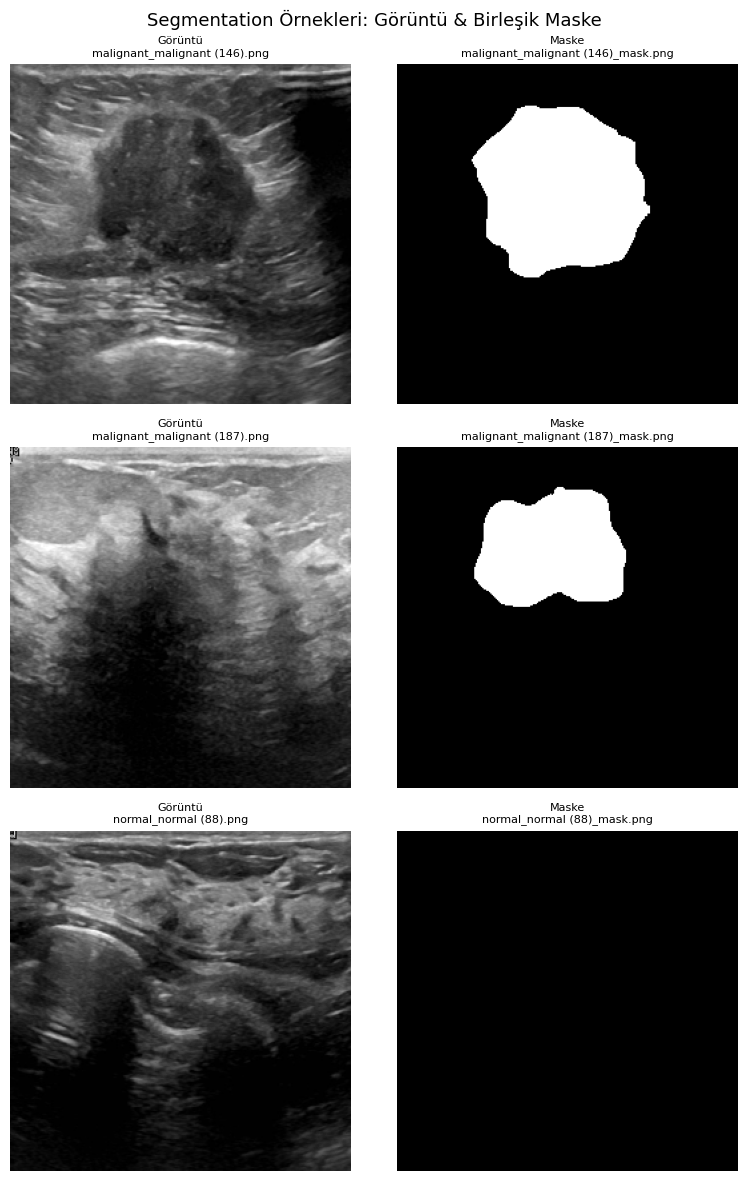


Doğrulama görseli kaydedildi → processed/dogrulama_ornekleri.png


In [23]:
import matplotlib.pyplot as plt
import random

# ─── 1. Sayısal Doğrulama ────────────────────────────────────────────────────
print("=" * 50)
print("KLASÖR BAZLI DOSYA SAYILARI")
print("=" * 50)

# Segmentation
seg_imgs  = glob(os.path.join(seg_img_dir, "*.png"))
seg_masks = glob(os.path.join(seg_mask_dir, "*.png"))
print(f"\nSegmentation")
print(f"  images : {len(seg_imgs)}")
print(f"  masks  : {len(seg_masks)}")
print(f"  Eşleşme: {'✅ Tamam' if len(seg_imgs)==len(seg_masks) else '❌ UYUŞMUYOR!'}")

# Classification
print(f"\nClassification")
for cat, d in cls_dirs.items():
    files = glob(os.path.join(d, "*.png"))
    print(f"  {cat:12s}: {len(files)}")

total_seg = len(seg_imgs)
total_cls = sum(len(glob(os.path.join(d,"*.png"))) for d in cls_dirs.values())
print(f"\nSegmentation toplam : {total_seg}")
print(f"Classification toplam: {total_cls}")
print(f"Genel eşleşme       : {'✅ Tamam' if total_seg==total_cls else '❌ UYUŞMUYOR!'}")

# ─── 2. Görsel Doğrulama (3 rastgele örnek) ──────────────────────────────────
sample_imgs = random.sample(seg_imgs, min(3, len(seg_imgs)))

fig, axes = plt.subplots(len(sample_imgs), 2, figsize=(8, 4 * len(sample_imgs)))
fig.suptitle("Segmentation Örnekleri: Görüntü & Birleşik Maske", fontsize=13)

for i, img_path in enumerate(sample_imgs):
    fname        = os.path.basename(img_path)
    mask_fname   = fname.replace(".png", "_mask.png")
    mask_path    = os.path.join(seg_mask_dir, mask_fname)

    img  = cv2.imread(img_path,  cv2.IMREAD_GRAYSCALE)
    
    ax_img, ax_mask = axes[i]
    ax_img.imshow(img, cmap="gray")
    ax_img.set_title(f"Görüntü\n{fname}", fontsize=8)
    ax_img.axis("off")
    
    if os.path.exists(mask_path):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        ax_mask.imshow(mask, cmap="gray")
        ax_mask.set_title(f"Maske\n{mask_fname}", fontsize=8)
    else:
        ax_mask.text(0.5, 0.5, "Maske bulunamadı!", ha="center", va="center", color="red")
        ax_mask.set_title("❌ Eksik Maske", fontsize=8)
    ax_mask.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, "dogrulama_ornekleri.png"), dpi=120)
plt.show()
print("\nDoğrulama görseli kaydedildi → processed/dogrulama_ornekleri.png")

-----------------------------
--------------
------------------

Toplam çift/çoklu maskeli görüntü sayısı: 17


C:\Users\dellg\AppData\Local\Temp\ipykernel_13696\2510839883.py:73: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\dellg\AppData\Local\Temp\ipykernel_13696\2510839883.py:75: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(out_path, dpi=120, bbox_inches="tight")
C:\Users\dellg\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


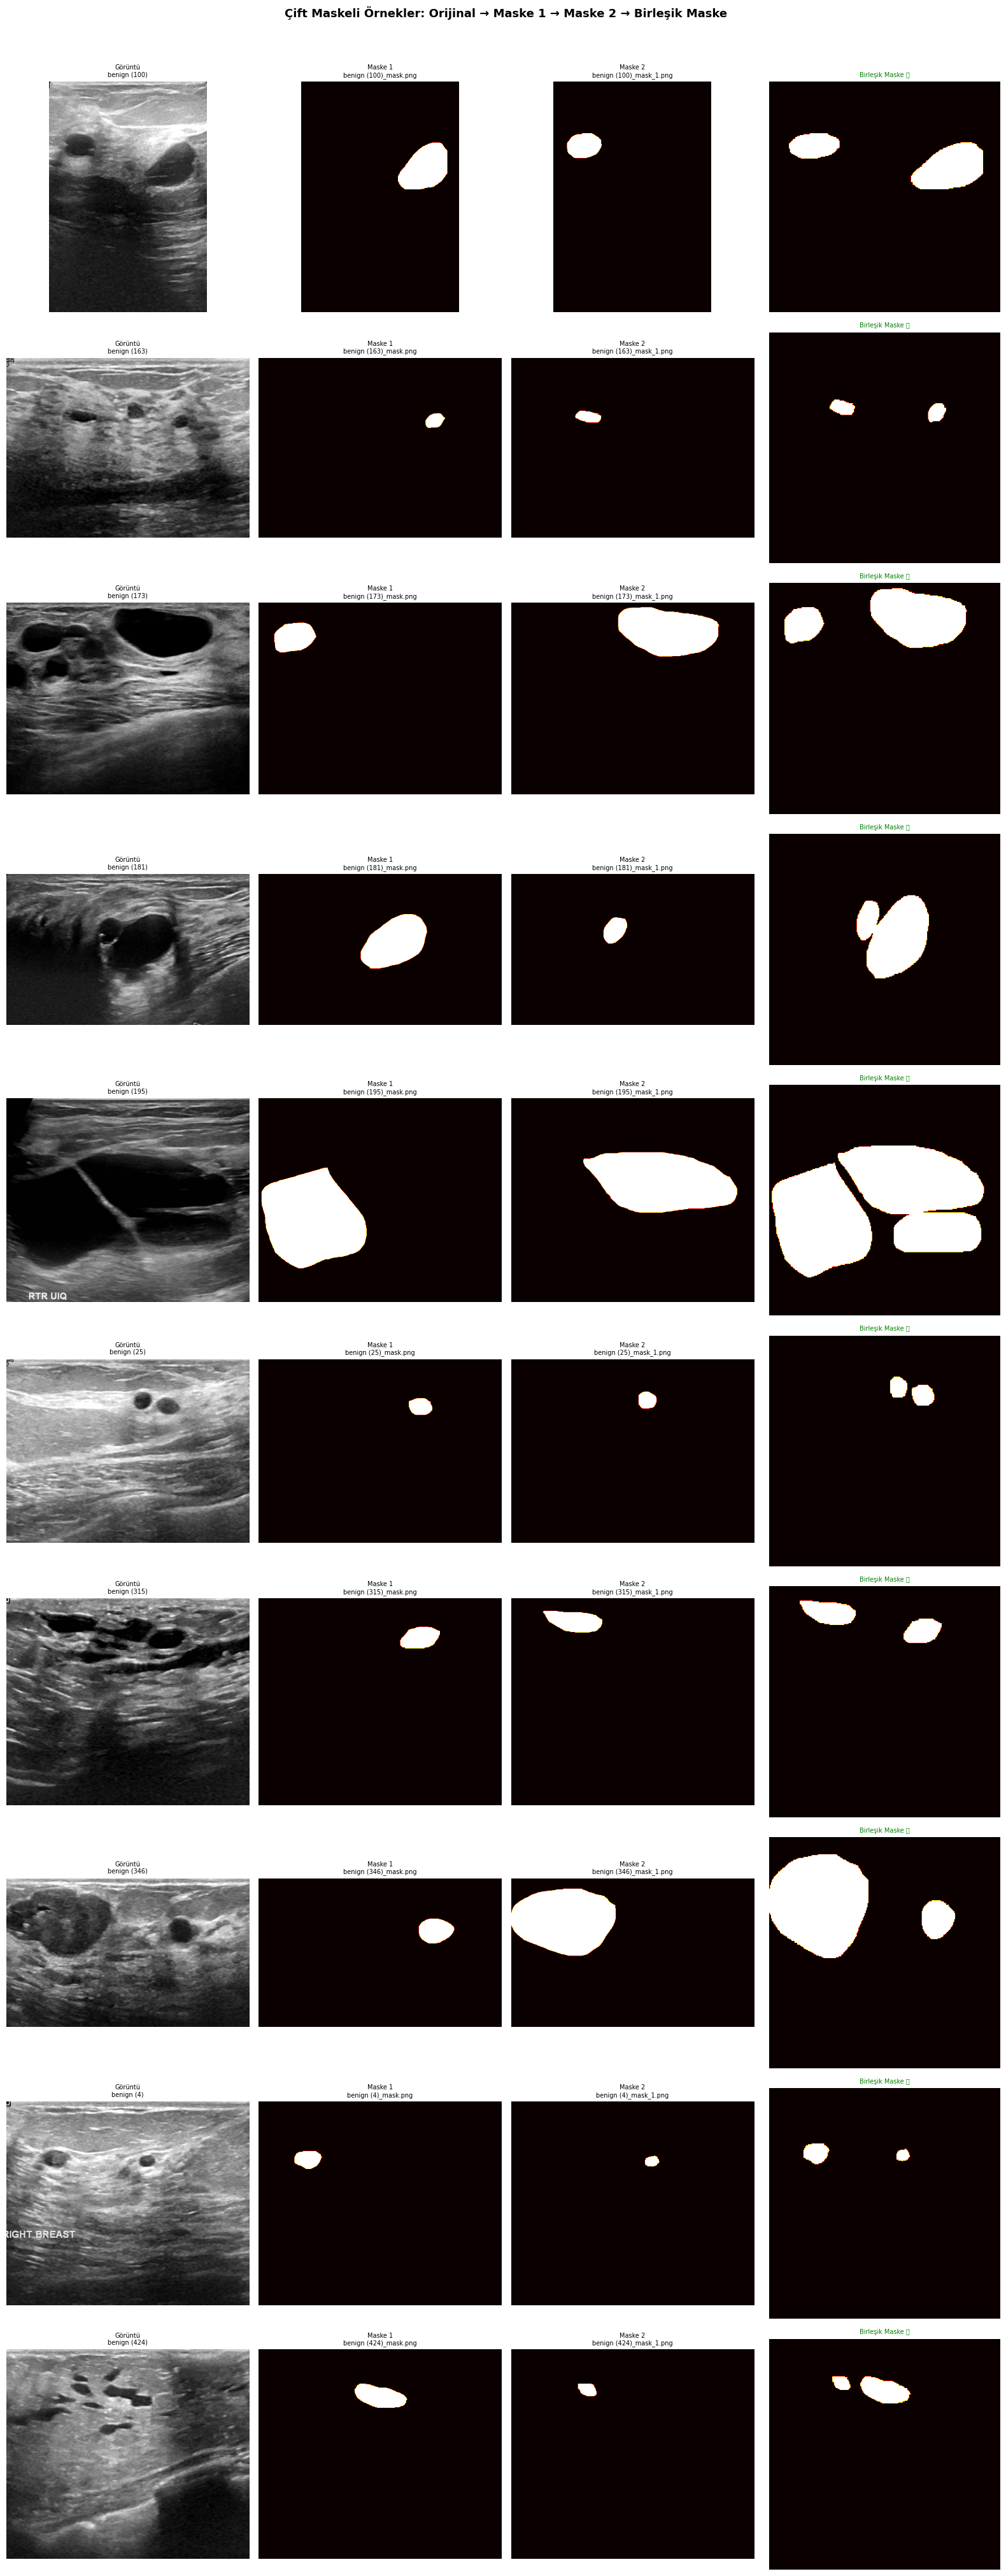


Doğrulama görseli kaydedildi → C:\ornekler\jupyter\deep_learning\breast-cancer\processed\cift_maske_dogrulama.png


In [24]:
import matplotlib.pyplot as plt
import os
from glob import glob

# ─── Çift (veya daha fazla) maskeli görüntüleri bul ──────────────────────────
dataset_dir = r"C:\ornekler\jupyter\deep_learning\breast-cancer\Dataset_BUSI_with_GT"
categories  = ["benign", "malignant", "normal"]

multi_mask_samples = []  # (img_path, [mask_path1, mask_path2, ...], combined_mask_path)

for category in categories:
    cat_dir     = os.path.join(dataset_dir, category)
    all_files   = sorted(glob(os.path.join(cat_dir, "*.png")))
    image_files = [f for f in all_files if "mask" not in os.path.basename(f)]

    for img_path in image_files:
        base_name  = os.path.splitext(os.path.basename(img_path))[0]
        mask_files = sorted(glob(os.path.join(cat_dir, f"{base_name}_mask*.png")))

        if len(mask_files) >= 2:  # Sadece çift veya daha fazla maskeli olanlar
            combined_fname = f"{category}_{base_name}_mask.png"
            combined_path  = os.path.join(
                r"C:\ornekler\jupyter\deep_learning\breast-cancer\processed\segmentation\masks",
                combined_fname
            )
            multi_mask_samples.append((img_path, mask_files, combined_path))

print(f"Toplam çift/çoklu maskeli görüntü sayısı: {len(multi_mask_samples)}")

# ─── İlk 10 örneği görselleştir ──────────────────────────────────────────────
samples = multi_mask_samples[:10]
n_cols  = 4   # Görüntü | Maske1 | Maske2 | Birleşik

fig, axes = plt.subplots(len(samples), n_cols, figsize=(16, 4 * len(samples)))
fig.suptitle("Çift Maskeli Örnekler: Orijinal → Maske 1 → Maske 2 → Birleşik Maske",
             fontsize=13, fontweight="bold", y=1.01)

for i, (img_path, mask_files, combined_path) in enumerate(samples):
    base_name = os.path.splitext(os.path.basename(img_path))[0]

    img    = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask1  = cv2.imread(mask_files[0], cv2.IMREAD_GRAYSCALE)
    mask2  = cv2.imread(mask_files[1], cv2.IMREAD_GRAYSCALE)
    combined = cv2.imread(combined_path, cv2.IMREAD_GRAYSCALE) \
               if os.path.exists(combined_path) else None

    row = axes[i]

    # Görüntü
    row[0].imshow(img, cmap="gray")
    row[0].set_title(f"Görüntü\n{base_name}", fontsize=7)

    # Maske 1
    row[1].imshow(mask1, cmap="hot")
    row[1].set_title(f"Maske 1\n{os.path.basename(mask_files[0])}", fontsize=7)

    # Maske 2
    row[2].imshow(mask2, cmap="hot")
    row[2].set_title(f"Maske 2\n{os.path.basename(mask_files[1])}", fontsize=7)

    # Birleşik Maske
    if combined is not None:
        row[3].imshow(combined, cmap="hot")
        row[3].set_title("Birleşik Maske ✅", fontsize=7, color="green")
    else:
        row[3].text(0.5, 0.5, "Bulunamadı!\nprocess_and_save()\nçalıştırıldı mı?",
                    ha="center", va="center", color="red", fontsize=8)
        row[3].set_title("Birleşik Maske ❌", fontsize=7, color="red")

    for ax in row:
        ax.axis("off")

plt.tight_layout()
out_path = r"C:\ornekler\jupyter\deep_learning\breast-cancer\processed\cift_maske_dogrulama.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"\nDoğrulama görseli kaydedildi → {out_path}")